In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("repository_data.csv")

In [3]:
threshold = df["stars_count"].quantile(0.75)

df["success"] = (df["stars_count"] > threshold).astype(int)
df_eda = df.sample(100000)

# full dataset for model
df_train = df

In [4]:
df.head()

,name,stars_count,forks_count,watchers,pull_requests,primary_language,languages_used,commit_count,created_at,licence,success
0,freeCodeCamp,359805,30814,8448,31867,TypeScript,"['TypeScript', 'JavaScript', 'CSS', 'Shell', '...",32231.0,2014-12-24T17:49:19Z,"BSD 3-Clause ""New"" or ""Revised"" License",1
1,996.ICU,264811,21470,4298,1949,NaN,NaN,3189.0,2019-03-26T07:31:14Z,Other,1
2,free-programming-books,262380,53302,9544,8235,NaN,NaN,8286.0,2013-10-11T06:50:37Z,Other,1
3,coding-interview-university,244927,65038,8539,867,NaN,NaN,2314.0,2016-06-06T02:34:12Z,Creative Commons Attribution Share Alike 4.0 I...,1
4,awesome,235223,24791,7446,1859,NaN,NaN,1074.0,2014-07-11T13:42:37Z,Creative Commons Zero v1.0 Universal,1


In [5]:
df.shape

(2917951, 11)

In [6]:
df.describe

<bound method NDFrame.describe of                                           name  stars_count  forks_count  \
0                                 freeCodeCamp       359805        30814   
1                                      996.ICU       264811        21470   
2                       free-programming-books       262380        53302   
3                  coding-interview-university       244927        65038   
4                                      awesome       235223        24791   
...                                        ...          ...          ...   
2917946                          FastledServer            6            1   
2917947                 zero-motorcycle-canbus            6            3   
2917948       common-object-management-service            6            7   
2917949  MSI-Z690-Carbon-i7-12700KF-Hackintosh            6            5   
2917950                                 bottle            6            0   

         watchers  pull_requests primary_language  \


In [7]:
df.isnull().sum()

name                     13
stars_count               0
forks_count               0
watchers                  0
pull_requests             0
primary_language     218573
languages_used       221984
commit_count           1921
created_at                0
licence             1378200
success                   0
dtype: int64

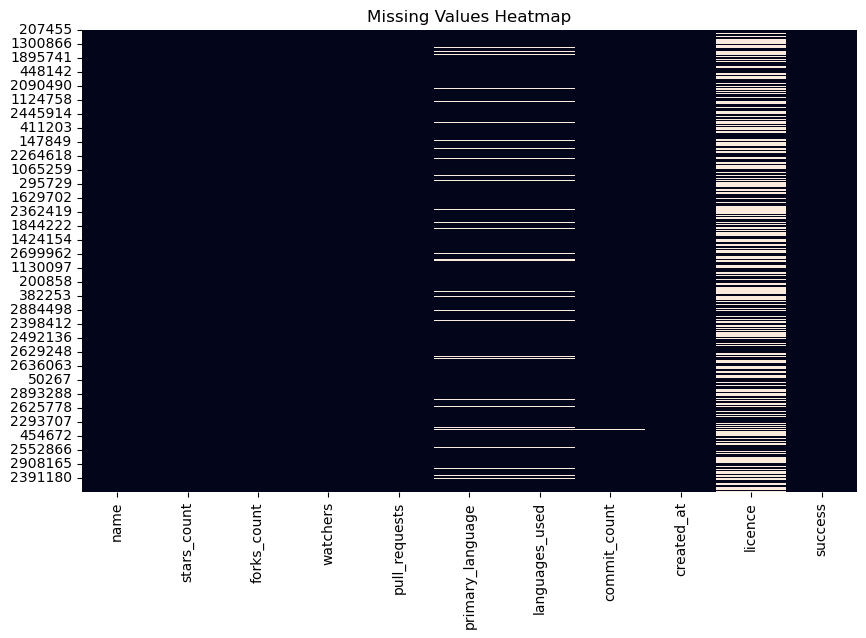

In [8]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df_eda.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns

df["commit_count"] = df["commit_count"].fillna(df["commit_count"].median())

In [10]:
df["primary_language"] = df["primary_language"].fillna("Unknown")

In [11]:
df = df.drop(columns=["name","licence","languages_used","created_at"])
df = df.drop("stars_count", axis=1)

In [12]:
df.isnull().sum()

forks_count         0
watchers            0
pull_requests       0
primary_language    0
commit_count        0
success             0
dtype: int64

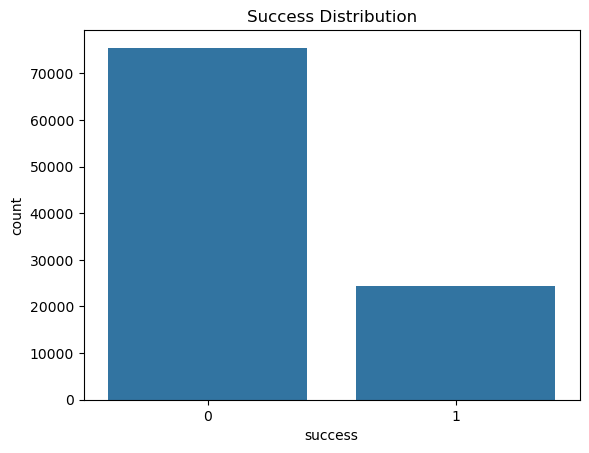

In [13]:
sns.countplot(x=df_eda["success"])
plt.title("Success Distribution")
plt.show()

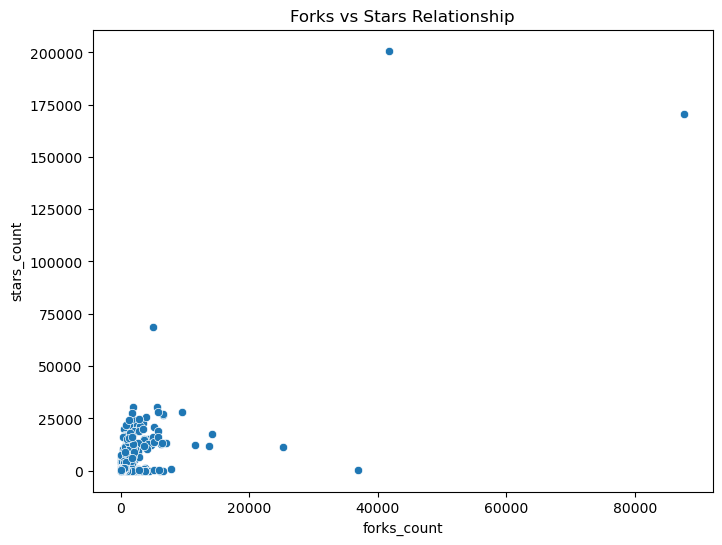

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="forks_count", y="stars_count", data=df_eda)

plt.title("Forks vs Stars Relationship")

plt.show()

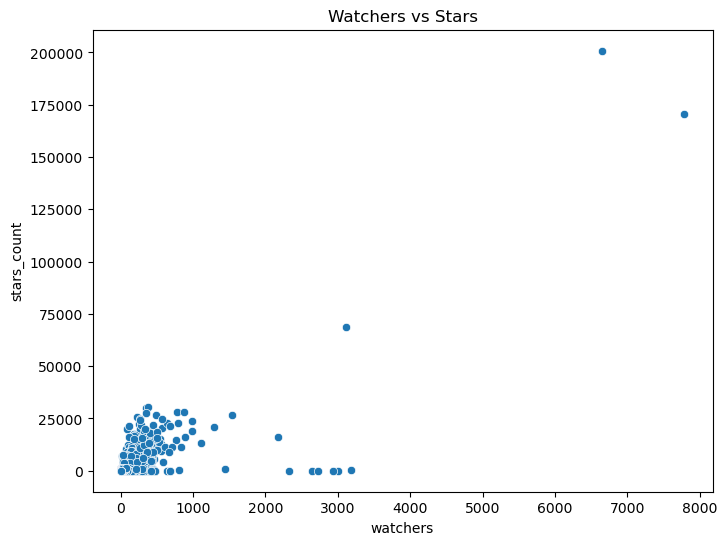

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="watchers", y="stars_count", data=df_eda)

plt.title("Watchers vs Stars")

plt.show()

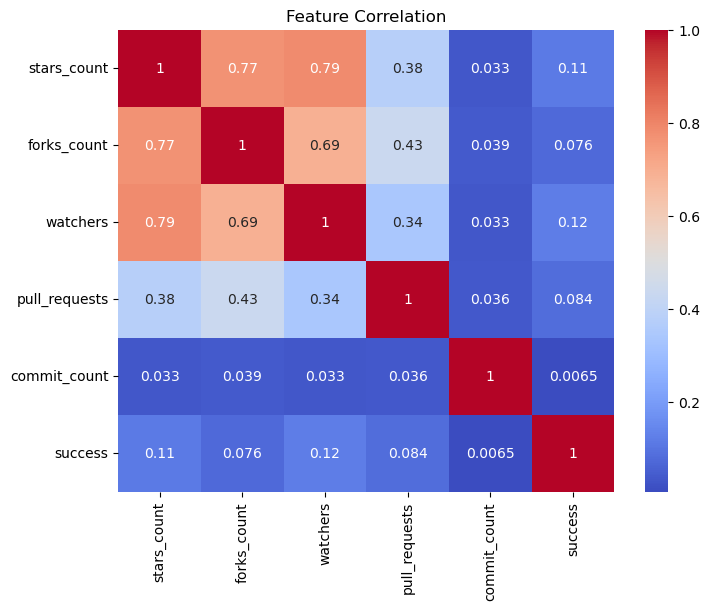

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(df_eda.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

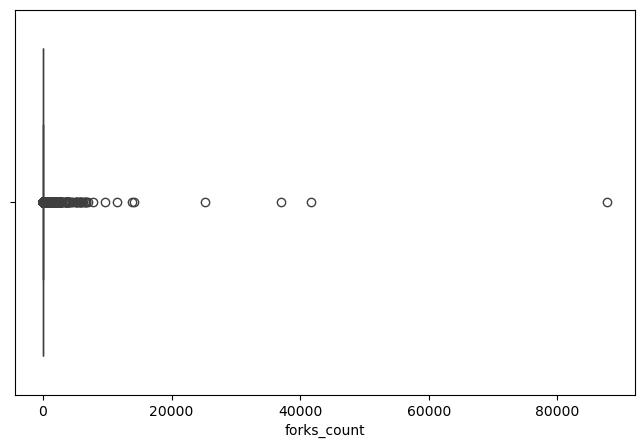

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_eda["forks_count"])
plt.show()

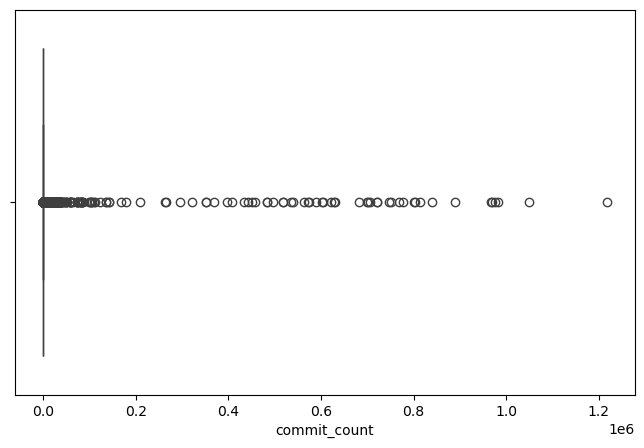

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_eda["commit_count"])
plt.show()

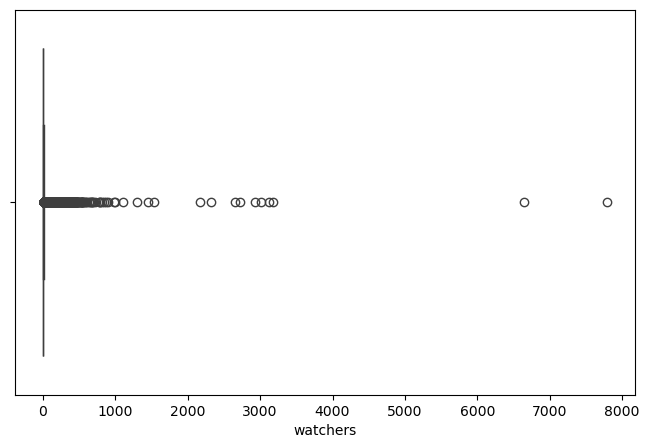

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_eda["watchers"])
plt.show()

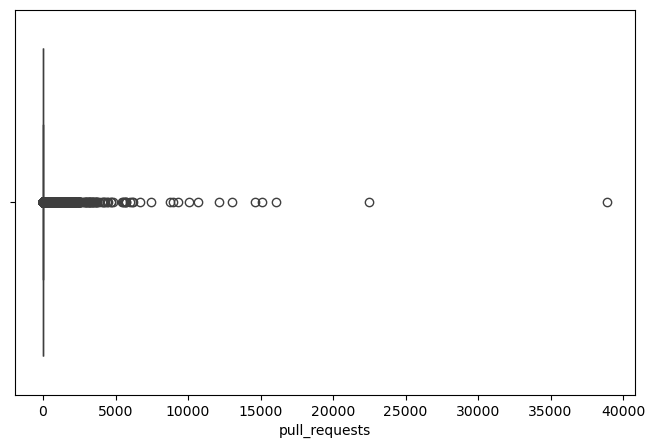

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_eda["pull_requests"])
plt.show()

In [21]:

df["forks_count"] = np.log1p(df["forks_count"])
df["watchers"] = np.log1p(df["watchers"])
df["pull_requests"] = np.log1p(df["pull_requests"])
df["commit_count"] = np.log1p(df["commit_count"])

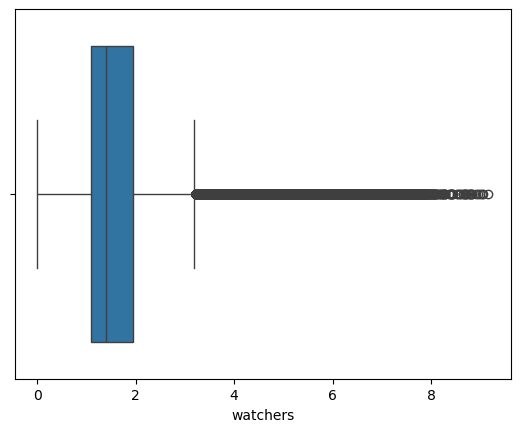

In [22]:
sns.boxplot(x=df["watchers"])
plt.show()

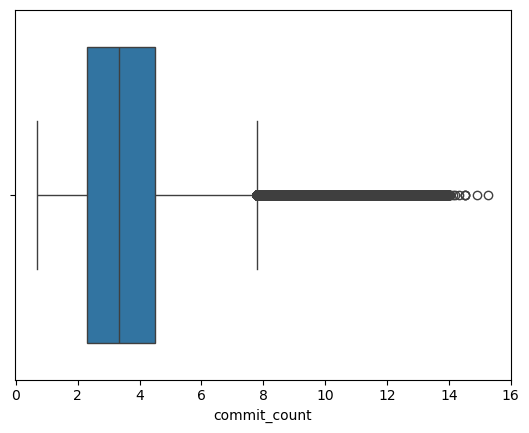

In [23]:
sns.boxplot(x=df["commit_count"])
plt.show()

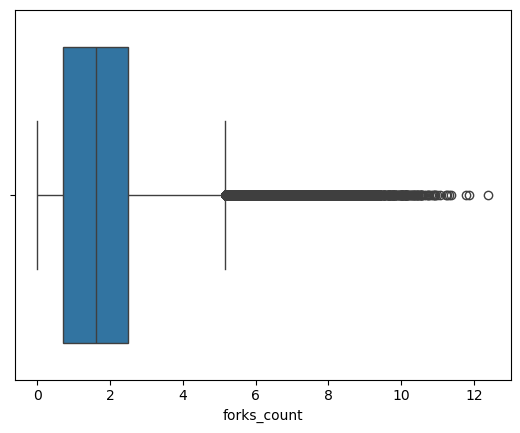

In [24]:
sns.boxplot(x=df["forks_count"])
plt.show()

In [25]:
df["engagement_score"] = (
    df["forks_count"] +
    df["watchers"] +
    df["pull_requests"]
)

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["primary_language"] = le.fit_transform(df["primary_language"])

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop("success", axis=1)
y = df["success"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000,class_weight="balanced")

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [30]:
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8291663168211985
              precision    recall  f1-score   support

           0       0.93      0.83      0.88    441325
           1       0.61      0.81      0.70    142266

    accuracy                           0.83    583591
   macro avg       0.77      0.82      0.79    583591
weighted avg       0.85      0.83      0.84    583591



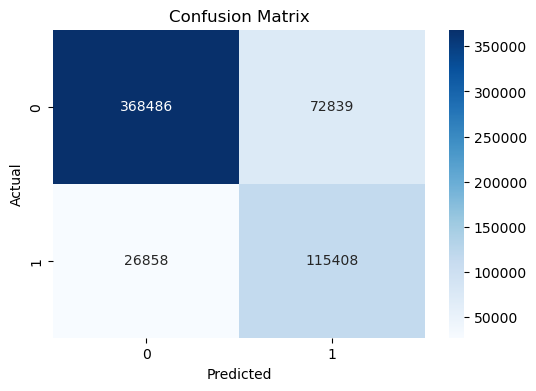

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

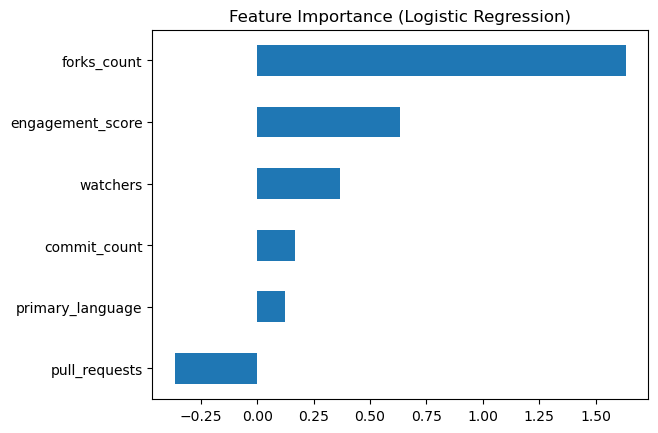

<Figure size 640x480 with 0 Axes>

In [43]:

importance = pd.Series(
    model.coef_[0],
    index=X.columns
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance (Logistic Regression)")
plt.show()
plt.savefig("feature_importance.png")

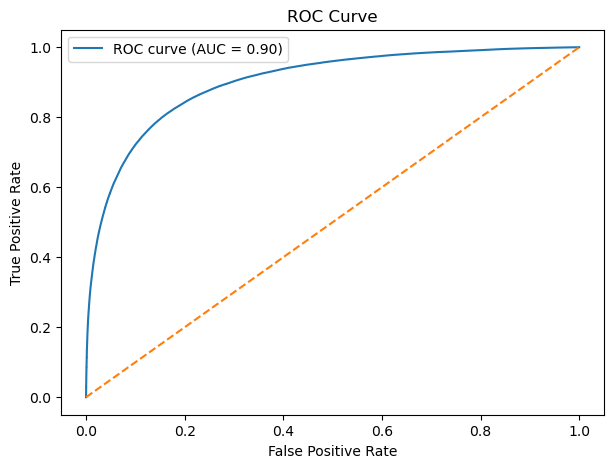

In [33]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

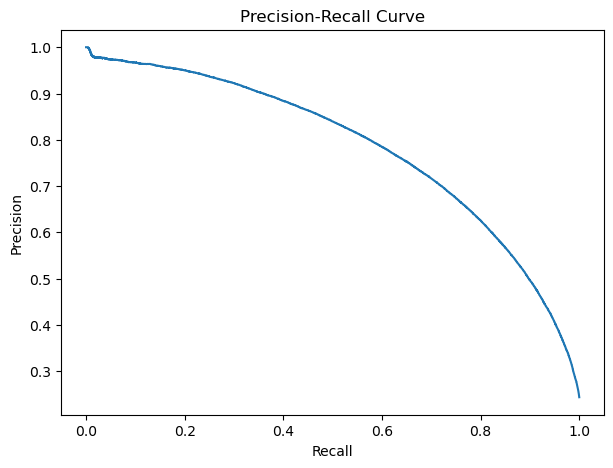

In [34]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [35]:
from sklearn.metrics import accuracy_score

train_pred = model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_acc)

Training Accuracy: 0.8305951095803561


In [36]:
test_pred = model.predict(X_test)

test_acc = accuracy_score(y_test, test_pred)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.8291663168211985


In [37]:
print(X.shape)
print(y.shape)

(2917951, 6)
(2917951,)


In [38]:
query = [[2.5, 1.8, 3.0, 4.2, 7.3, 5]]

prediction = model.predict(query)

print("Prediction:", prediction)

Prediction: [1]


In [39]:
prob = model.predict_proba(query)

print("Success Probability:", prob[:,1])

Success Probability: [0.99961675]


In [41]:
import joblib

joblib.dump(model, "repo_success_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']